# 03 - IRF and FEVD: Complete Solution

This is the **complete solution** for the IRF and FEVD notebook.
All exercises are fully resolved with outputs saved.

---

## Topics covered

1. Orthogonalized IRF (Cholesky decomposition)
2. Generalized IRF (Pesaran-Shin)
3. Bootstrap confidence intervals
4. Cumulative IRF
5. Forecast Error Variance Decomposition (FEVD)
6. **Exercise 1: Monetary policy shocks on US Macro** (SOLVED)
7. **Exercise 2: Variable ordering sensitivity** (SOLVED)

---

### Impulse Response Functions

$$Y_t = \sum_{i=0}^{\infty} \Phi_i u_{t-i}$$

The IRF at horizon $h$: $\Phi_h[i,j]$ = response of variable $i$ to shock in variable $j$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import sys
import os

from chronobox import VAR
from chronobox.analysis.irf import IRF
from chronobox.analysis.fevd import FEVD

sys.path.insert(0, os.path.join("..", "utils"))
from plot_helpers import plot_irf, plot_fevd

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
np.set_printoptions(precision=4, suppress=True)

print("All imports loaded successfully.")

All imports loaded successfully.


## 1. Baseline VAR model (Canadian data)

In [2]:
data_path = os.path.join("..", "data", "canada_macro.csv")
df = pd.read_csv(data_path)
var_names = ["e", "prod", "rw", "U"]
endog = df[var_names].values

model = VAR(lags=2, trend="c")
results = model.fit(endog, names=var_names)

print(f"VAR({results.k_ar}) fitted with {results.neqs} equations")
print(f"Stable: {results.is_stable}")
print(f"AIC: {results.aic:.4f}")

VAR(2) fitted with 4 equations
Stable: True
AIC: -62.9240


## 2. Orthogonalized IRF (Cholesky)

Ordering: `e -> prod -> rw -> U`

In [3]:
irf_cholesky = results.irf(periods=20, method="cholesky", sigs=0.95, runs=500)

print(f"IRF shape: {irf_cholesky.irfs.shape}")
print(f"  (periods+1, K_response, K_shock) = ({irf_cholesky.irfs.shape[0]}, "
      f"{irf_cholesky.irfs.shape[1]}, {irf_cholesky.irfs.shape[2]})")
print(f"Bootstrap bands available: {irf_cholesky.lower is not None}")

IRF shape: (21, 4, 4)
  (periods+1, K_response, K_shock) = (21, 4, 4)
Bootstrap bands available: True


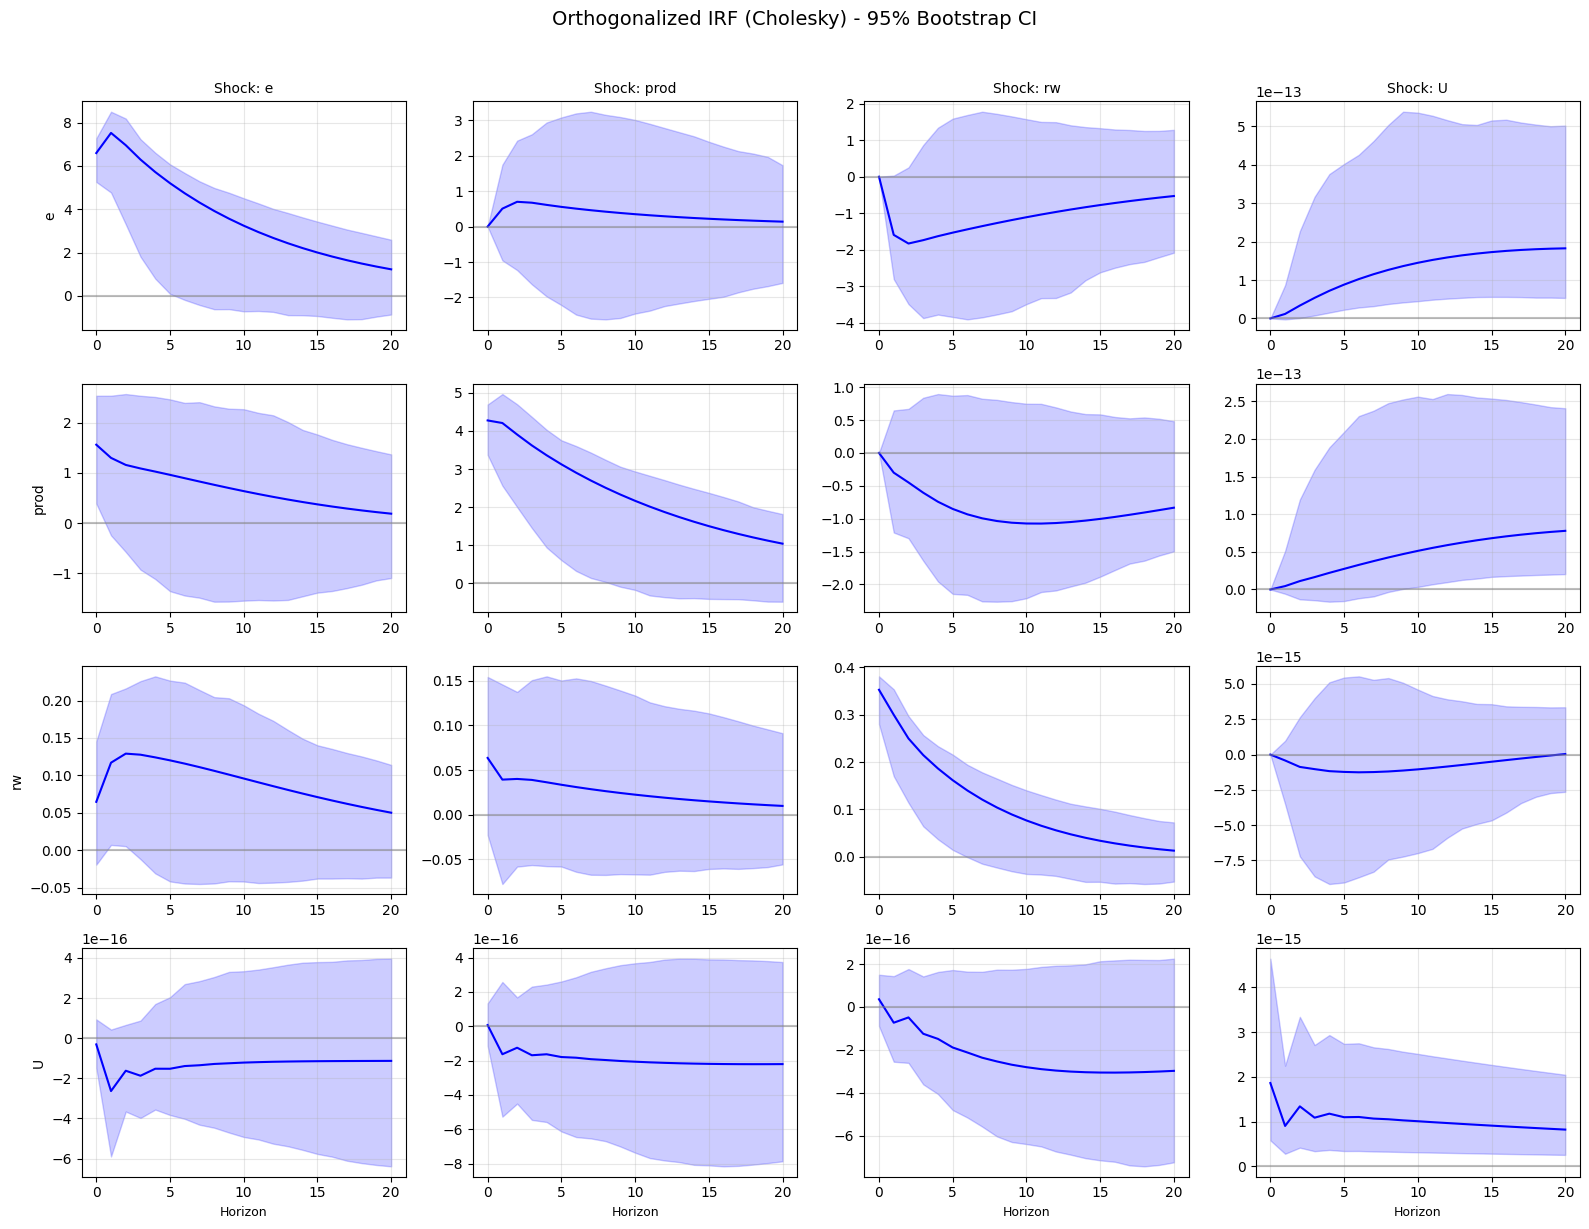

In [4]:
fig = irf_cholesky.plot(figsize=(16, 12))
plt.suptitle("Orthogonalized IRF (Cholesky) - 95% Bootstrap CI", fontsize=14, y=1.02)
plt.show()

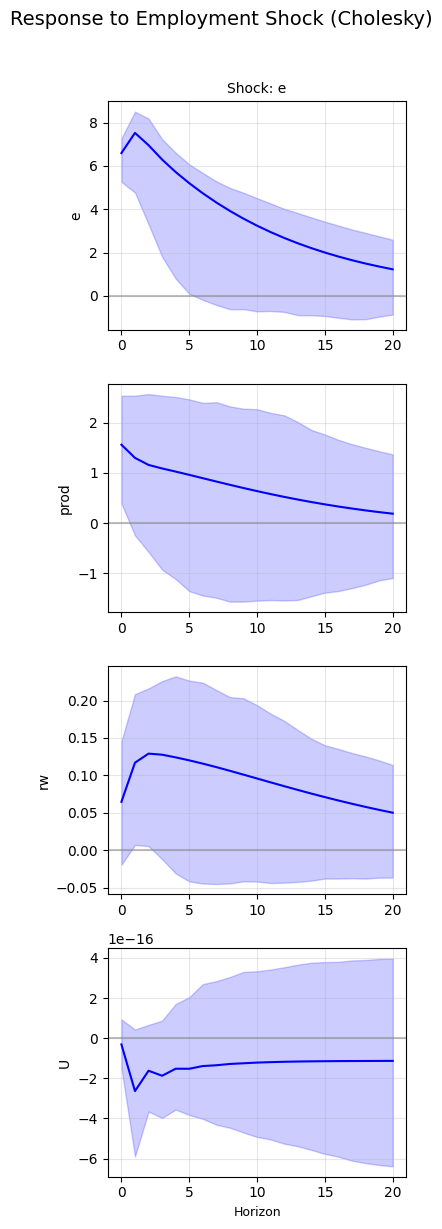

In [5]:
fig = irf_cholesky.plot(impulse="e")
plt.suptitle("Response to Employment Shock (Cholesky)", fontsize=14, y=1.02)
plt.show()

## 3. Generalized IRF (Pesaran-Shin)

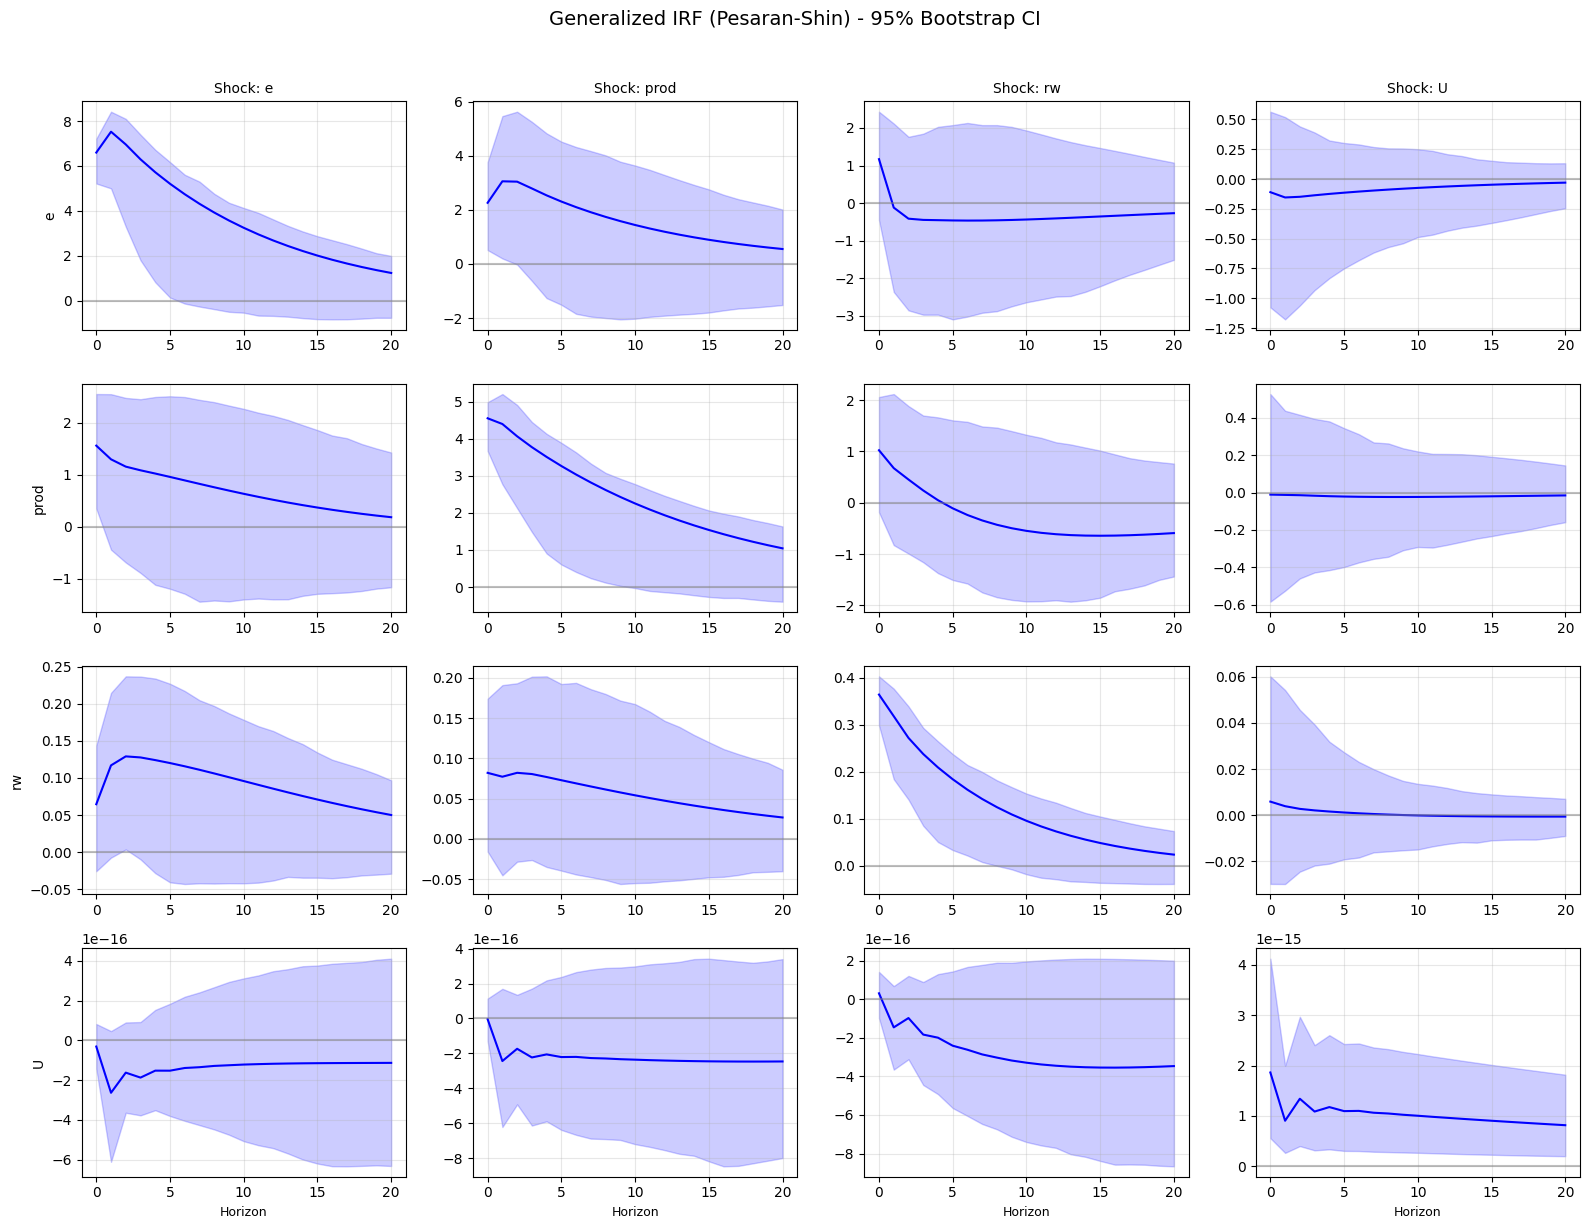

In [6]:
irf_generalized = results.irf(periods=20, method="generalized", sigs=0.95, runs=500)

fig = irf_generalized.plot(figsize=(16, 12))
plt.suptitle("Generalized IRF (Pesaran-Shin) - 95% Bootstrap CI", fontsize=14, y=1.02)
plt.show()

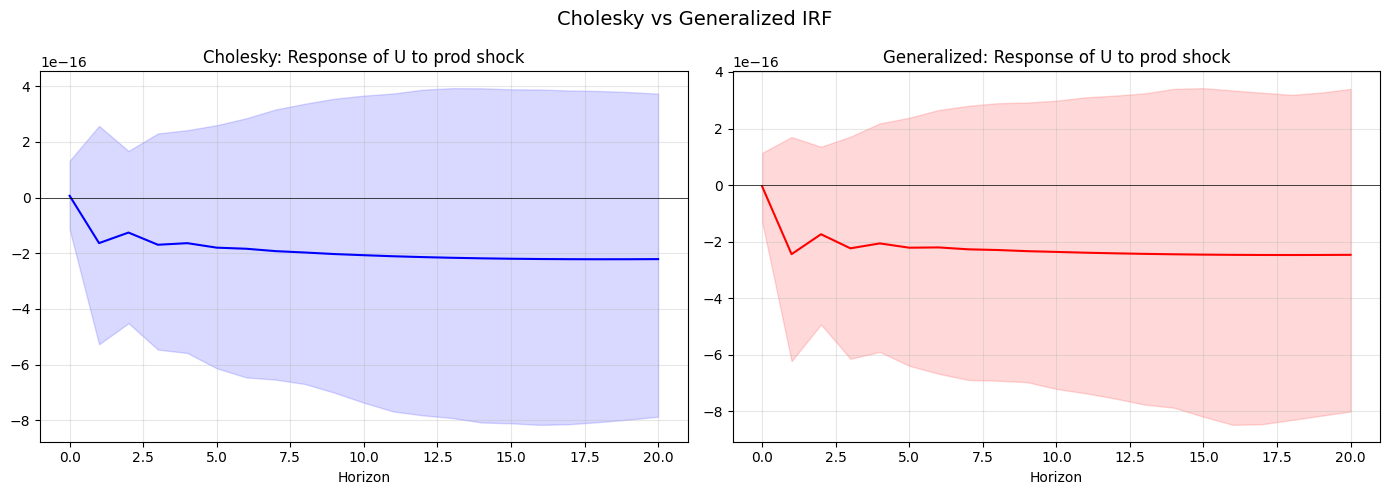

In [7]:
# Cholesky vs Generalized comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
horizons = np.arange(irf_cholesky.irfs.shape[0])

shock_idx = var_names.index("prod")
resp_idx = var_names.index("U")

ax = axes[0]
ax.plot(horizons, irf_cholesky.irfs[:, resp_idx, shock_idx], "b-", label="Cholesky", linewidth=1.5)
if irf_cholesky.lower is not None:
    ax.fill_between(horizons, irf_cholesky.lower[:, resp_idx, shock_idx],
                    irf_cholesky.upper[:, resp_idx, shock_idx], alpha=0.15, color="blue")
ax.axhline(0, color="k", linewidth=0.5)
ax.set_title("Cholesky: Response of U to prod shock")
ax.set_xlabel("Horizon")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(horizons, irf_generalized.irfs[:, resp_idx, shock_idx], "r-", label="Generalized", linewidth=1.5)
if irf_generalized.lower is not None:
    ax.fill_between(horizons, irf_generalized.lower[:, resp_idx, shock_idx],
                    irf_generalized.upper[:, resp_idx, shock_idx], alpha=0.15, color="red")
ax.axhline(0, color="k", linewidth=0.5)
ax.set_title("Generalized: Response of U to prod shock")
ax.set_xlabel("Horizon")
ax.grid(True, alpha=0.3)

plt.suptitle("Cholesky vs Generalized IRF", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Cumulative IRF

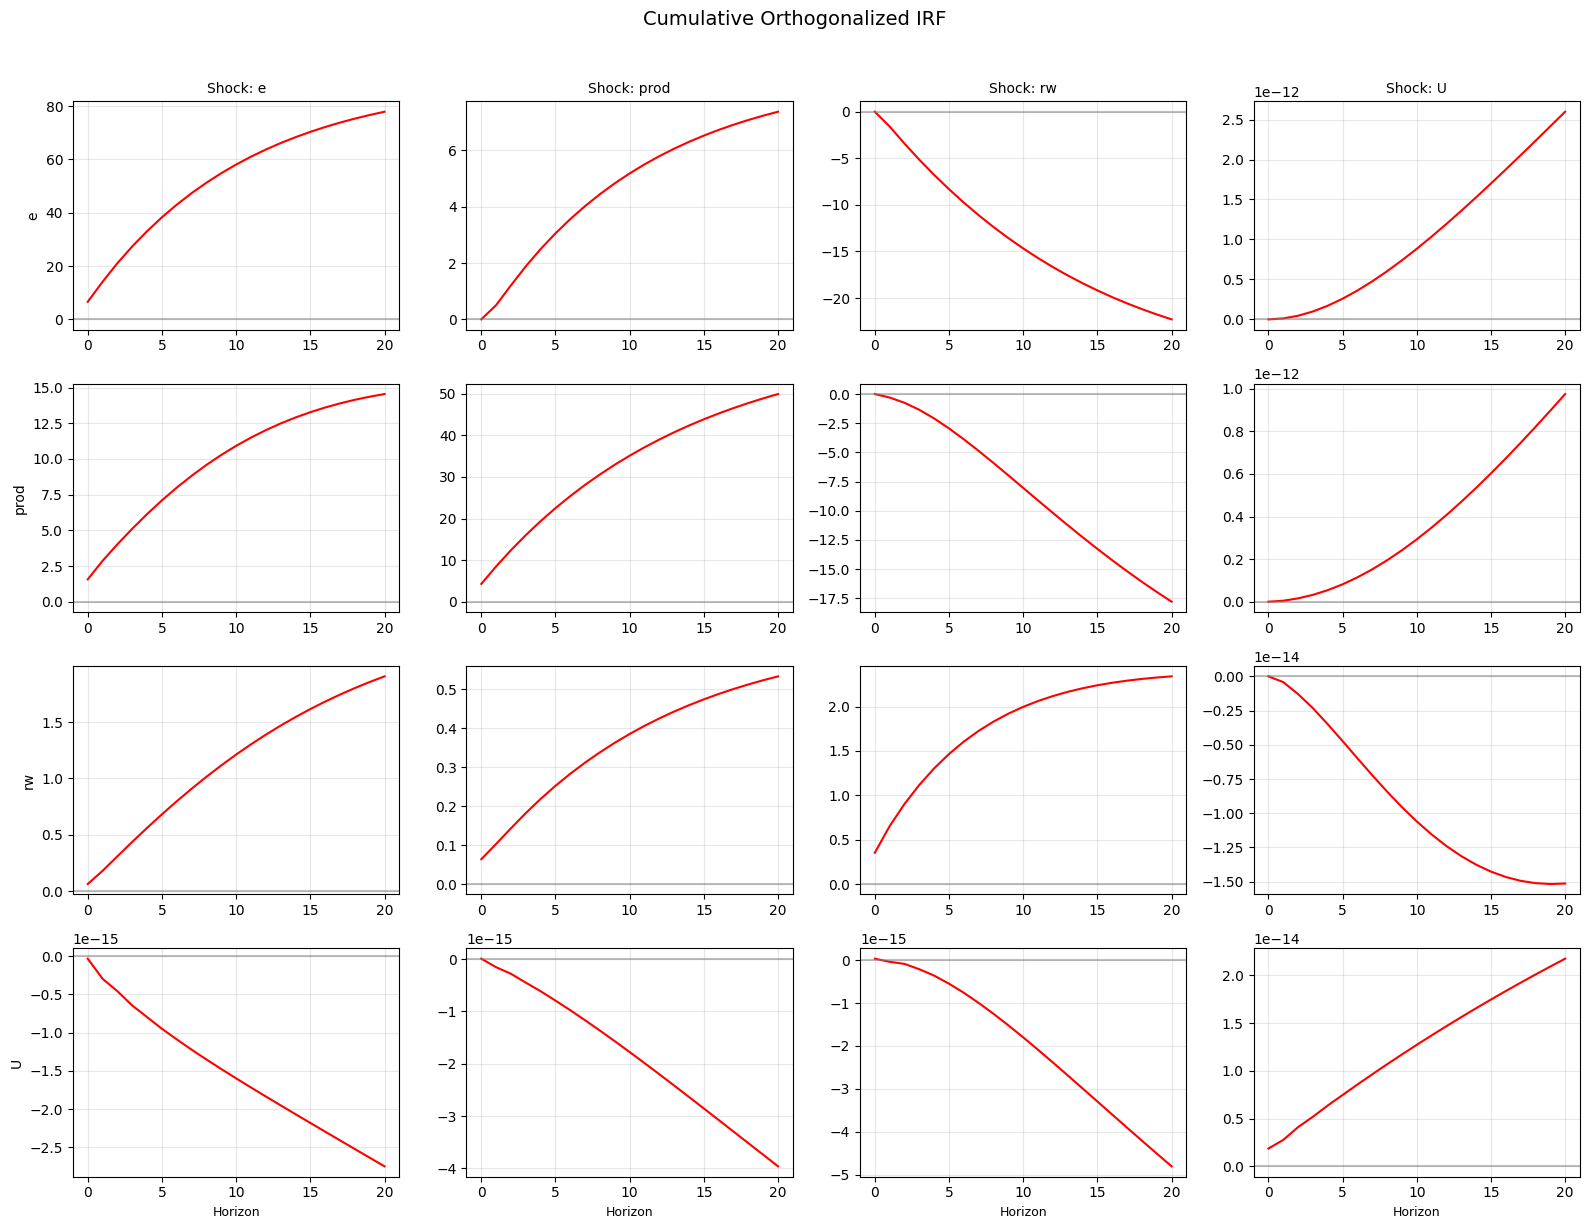

In [8]:
fig = irf_cholesky.plot_cum(figsize=(16, 12))
plt.suptitle("Cumulative Orthogonalized IRF", fontsize=14, y=1.02)
plt.show()

In [9]:
irf_df = irf_cholesky.to_dataframe()
print(f"IRF DataFrame shape: {irf_df.shape}")
print(f"Columns: {list(irf_df.columns)}")
irf_df.head(10)

IRF DataFrame shape: (336, 6)
Columns: ['horizon', 'impulse', 'response', 'irf', 'lower', 'upper']


,horizon,impulse,response,irf,lower,upper
0,0,e,e,6.594871e+00,5.263171e+00,7.275024e+00
1,0,e,prod,1.563224e+00,3.894456e-01,2.540356e+00
2,0,e,rw,6.457191e-02,-1.943585e-02,1.453632e-01
3,0,e,U,-3.108136e-17,-1.484154e-16,9.372796e-17
4,0,prod,e,0.000000e+00,0.000000e+00,0.000000e+00
5,0,prod,prod,4.276589e+00,3.372604e+00,4.693719e+00
6,0,prod,rw,6.362781e-02,-2.269342e-02,1.542364e-01
7,0,prod,U,6.521876e-18,-1.145225e-16,1.327746e-16
8,0,rw,e,0.000000e+00,0.000000e+00,0.000000e+00
9,0,rw,prod,0.000000e+00,0.000000e+00,0.000000e+00


## 5. Forecast Error Variance Decomposition (FEVD)

$$\theta_{ij}(h) = \frac{\sum_{s=0}^{h-1} (e_i' \Phi_s P e_j)^2}{\sum_{s=0}^{h-1} e_i' \Phi_s \Sigma_u \Phi_s' e_i}$$

In [10]:
fevd = results.fevd(periods=20, method="cholesky")

print(f"FEVD decomposition shape: {fevd.decomp.shape}")
print()
print(fevd.summary())

FEVD decomposition shape: (21, 4, 4)

  Forecast Error Variance Decomposition

  Response variable: e
------------------------------------------------------------------------------
   Horizon           e        prod          rw           U
  --------------------------------------------------------
         0      1.0000      0.0000      0.0000      0.0000
         1      0.9728      0.0025      0.0247      0.0000
         2      0.9573      0.0048      0.0379      0.0000
         5      0.9402      0.0072      0.0527      0.0000
        10      0.9295      0.0080      0.0625      0.0000
        20      0.9217      0.0083      0.0700      0.0000

  Response variable: prod
------------------------------------------------------------------------------
   Horizon           e        prod          rw           U
  --------------------------------------------------------
         0      0.1179      0.8821      0.0000      0.0000
         1      0.1028      0.8950      0.0022      0.0000
     

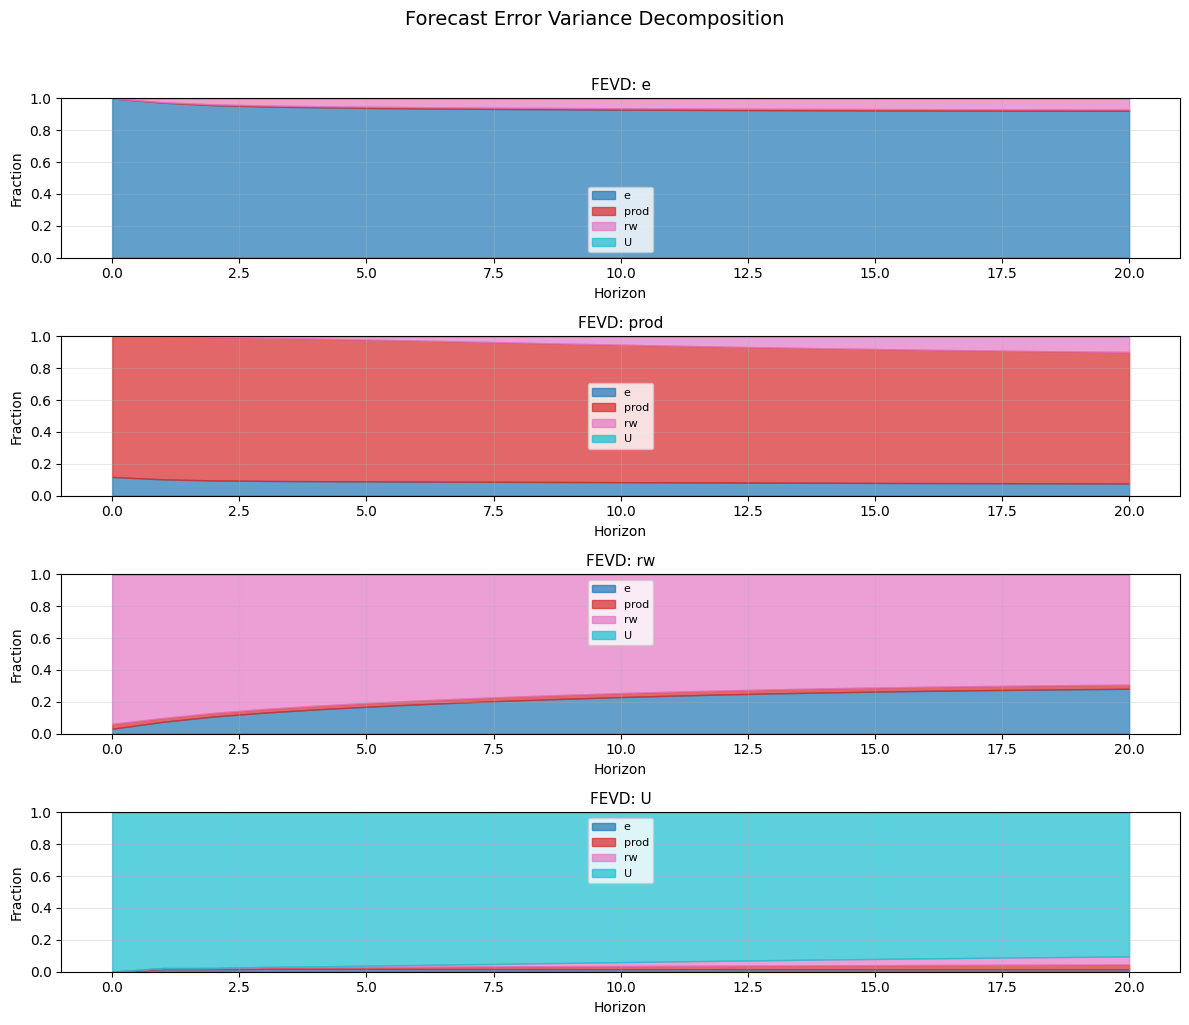

In [11]:
fig = fevd.plot(figsize=(12, 10))
plt.suptitle("Forecast Error Variance Decomposition", fontsize=14, y=1.02)
plt.show()

In [12]:
fevd_df = fevd.to_dataframe()

for h in [1, 5, 10, 20]:
    print(f"\nFEVD at horizon {h}:")
    subset = fevd_df[fevd_df["horizon"] == h].pivot(
        index="response", columns="shock", values="fevd"
    )
    print(subset.round(4).to_string())


FEVD at horizon 1:
shock          U       e    prod      rw
response                                
U         0.9763  0.0161  0.0061  0.0015
e         0.0000  0.9728  0.0025  0.0247
prod      0.0000  0.1028  0.8950  0.0022
rw        0.0000  0.0749  0.0235  0.9015

FEVD at horizon 5:
shock          U       e    prod      rw
response                                
U         0.9618  0.0174  0.0127  0.0081
e         0.0000  0.9402  0.0072  0.0527
prod      0.0000  0.0900  0.8899  0.0202
rw        0.0000  0.1692  0.0235  0.8073

FEVD at horizon 10:
shock          U       e    prod      rw
response                                
U         0.9398  0.0161  0.0198  0.0244
e         0.0000  0.9295  0.0080  0.0625
prod      0.0000  0.0851  0.8625  0.0524
rw        0.0000  0.2300  0.0248  0.7451

FEVD at horizon 20:
shock         U       e    prod      rw
response                               
U         0.904  0.0152  0.0308  0.0501
e         0.000  0.9217  0.0083  0.0700
prod      0.000  0.0

---

## Exercise 1: Monetary Policy Shocks - US Macro (SOLUTION)

Ordering: `gdp -> inflation -> fed_funds -> unemployment`

1. Fit VAR(4)
2. Compute orthogonalized IRF with 24 periods and 500 bootstrap replications
3. Plot response of GDP and unemployment to a fed_funds shock
4. Interpret: Does monetary tightening reduce GDP? Increase unemployment?
5. **Save IRF and FEVD results to CSV**

In [13]:
# Step 1: Load and fit VAR(4) on US macro data
us_df = pd.read_csv(os.path.join("..", "data", "us_macro_quarterly.csv"))
us_names = ["gdp", "inflation", "fed_funds", "unemployment"]
us_endog = us_df[us_names].values

us_model = VAR(lags=4, trend="c")
us_results = us_model.fit(us_endog, names=us_names)

print(f"US VAR(4): {us_results.neqs} equations, {us_results.nobs} effective obs")
print(f"Stable: {us_results.is_stable}")
print(f"AIC: {us_results.aic:.4f}, BIC: {us_results.bic:.4f}")

US VAR(4): 4 equations, 196 effective obs
Stable: True
AIC: -6.3476, BIC: -5.2772


In [14]:
# Step 2: Orthogonalized IRF with 24 periods
us_irf = us_results.irf(periods=24, method="cholesky", sigs=0.95, runs=500)

print(f"US IRF shape: {us_irf.irfs.shape}")
print(f"Bootstrap confidence bands: {us_irf.lower is not None}")

US IRF shape: (25, 4, 4)
Bootstrap confidence bands: True


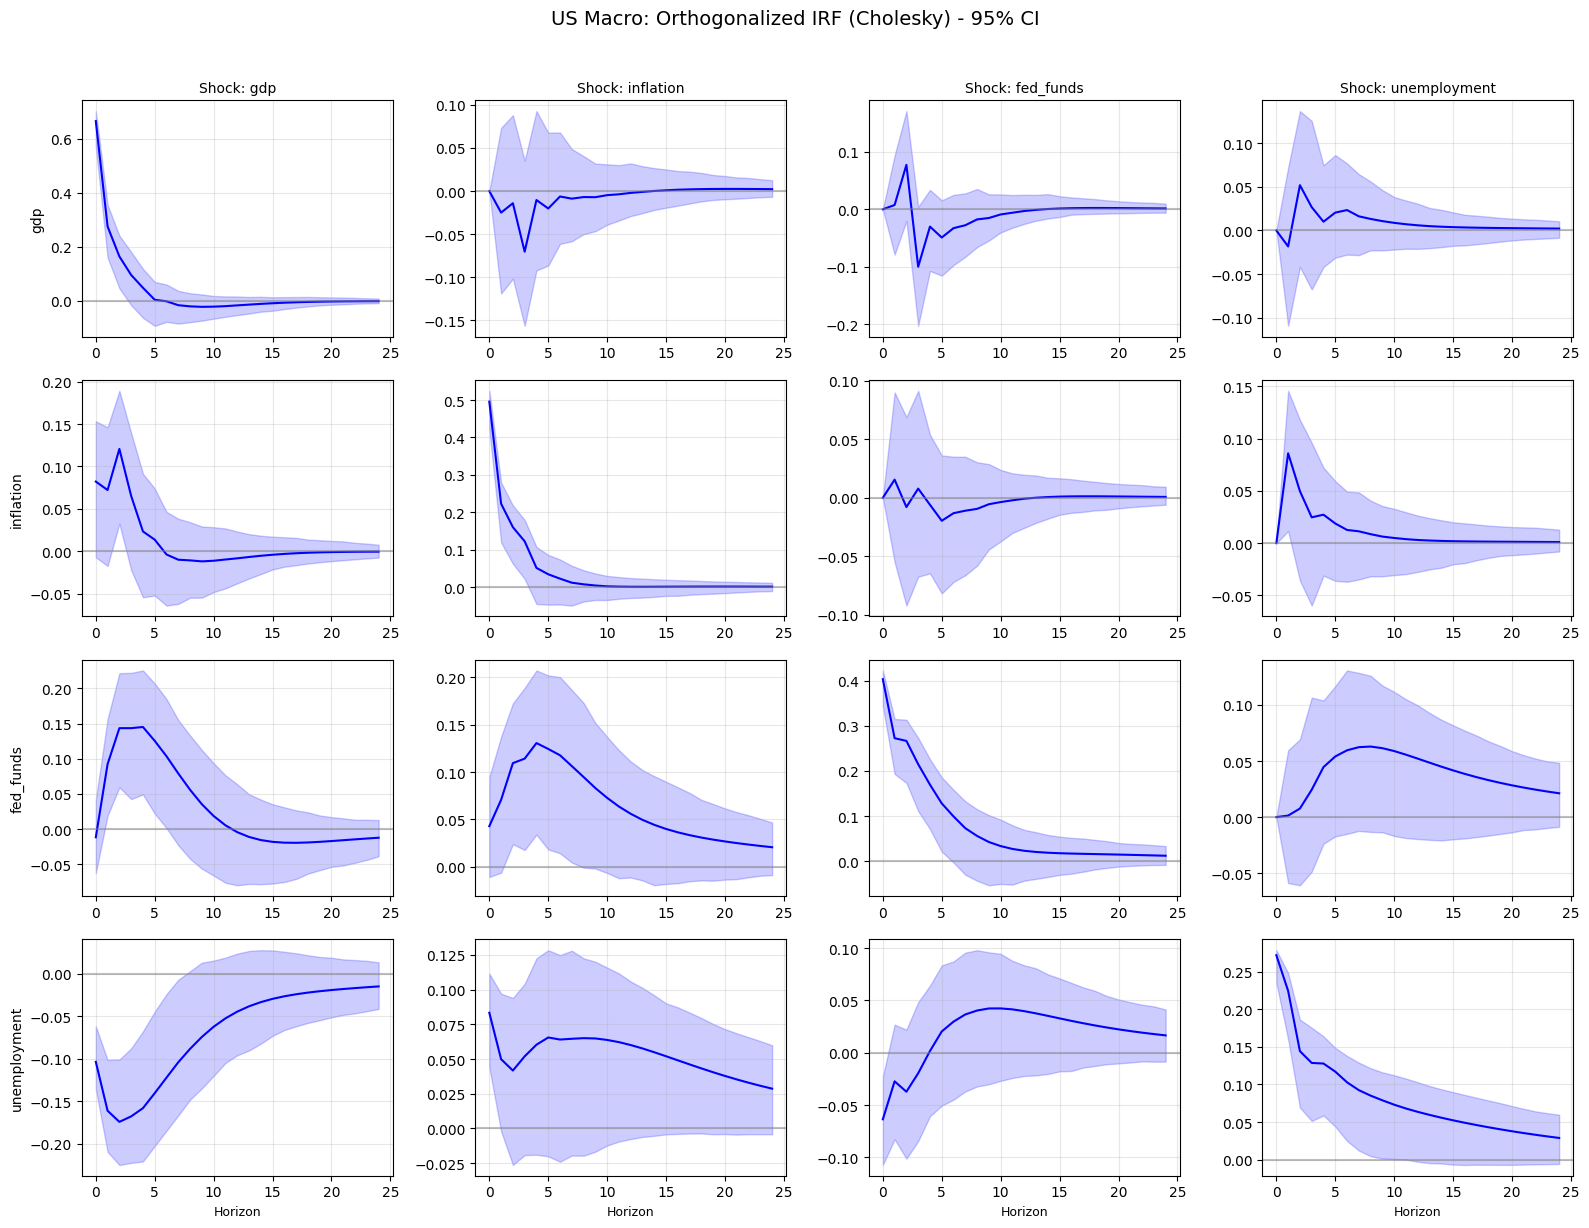

In [15]:
# Full IRF grid
fig = us_irf.plot(figsize=(16, 12))
plt.suptitle("US Macro: Orthogonalized IRF (Cholesky) - 95% CI", fontsize=14, y=1.02)
plt.show()

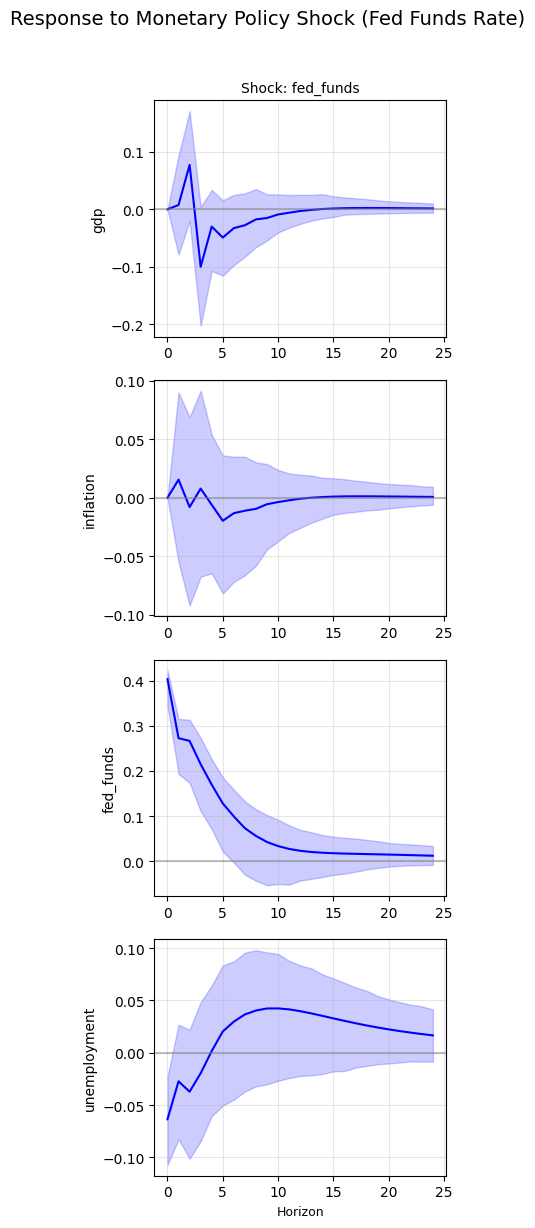

In [16]:
# Step 3: Focus on monetary policy shock (fed_funds)
fig = us_irf.plot(impulse="fed_funds")
plt.suptitle("Response to Monetary Policy Shock (Fed Funds Rate)", fontsize=14, y=1.02)
plt.show()

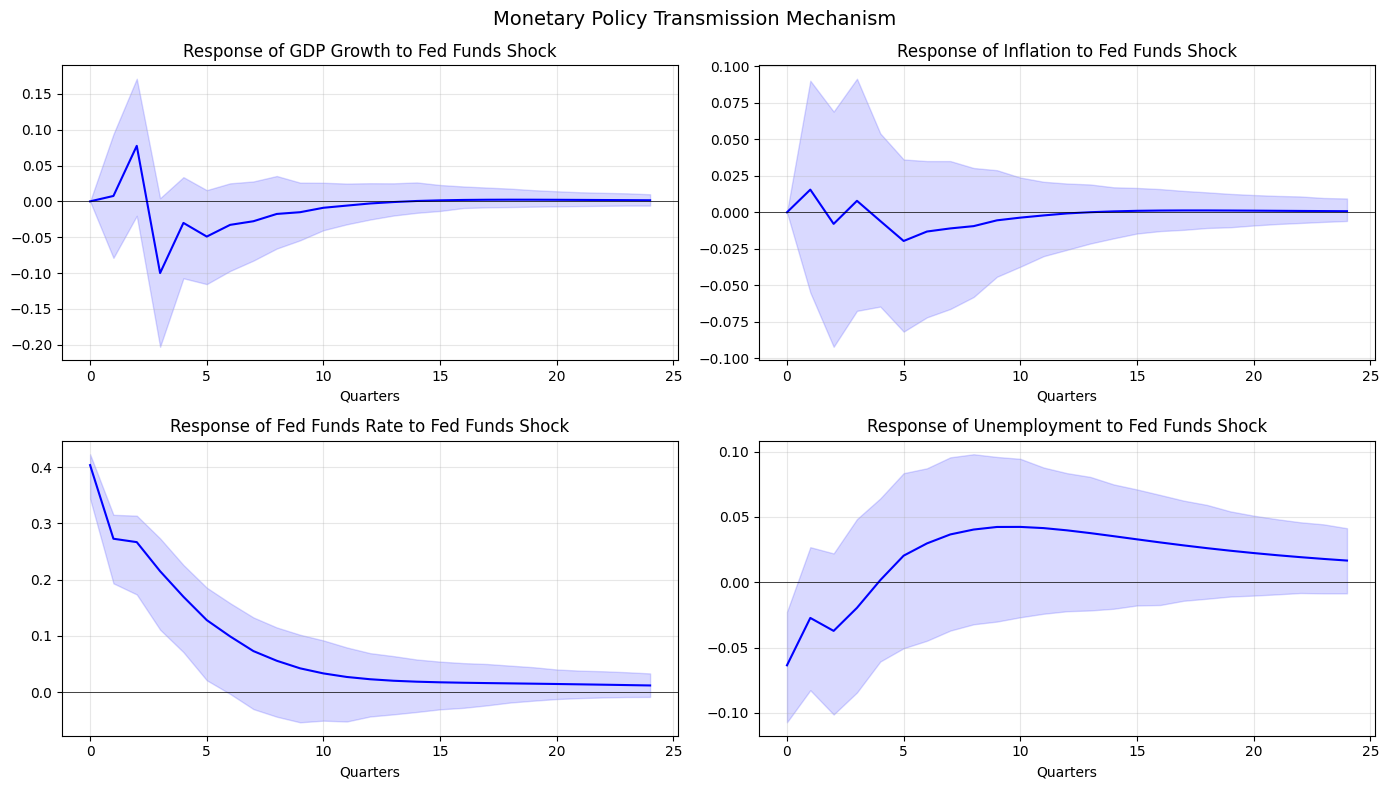

In [17]:
# Detailed analysis: GDP and unemployment response to fed_funds shock
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
horizons = np.arange(us_irf.irfs.shape[0])
ff_idx = us_names.index("fed_funds")

responses = [("gdp", "GDP Growth"), ("inflation", "Inflation"),
             ("fed_funds", "Fed Funds Rate"), ("unemployment", "Unemployment")]

for ax, (var, label) in zip(axes.flat, responses):
    resp_idx = us_names.index(var)
    ax.plot(horizons, us_irf.irfs[:, resp_idx, ff_idx], "b-", linewidth=1.5)
    if us_irf.lower is not None:
        ax.fill_between(horizons, us_irf.lower[:, resp_idx, ff_idx],
                        us_irf.upper[:, resp_idx, ff_idx], alpha=0.15, color="blue")
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_title(f"Response of {label} to Fed Funds Shock")
    ax.set_xlabel("Quarters")
    ax.grid(True, alpha=0.3)

plt.suptitle("Monetary Policy Transmission Mechanism", fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# Step 4: Interpretation
print("=" * 60)
print("MONETARY POLICY SHOCK ANALYSIS")
print("=" * 60)

ff_idx = us_names.index("fed_funds")

for var in ["gdp", "inflation", "unemployment"]:
    resp_idx = us_names.index(var)
    irfs = us_irf.irfs[:, resp_idx, ff_idx]
    
    peak = irfs[1:].max()
    trough = irfs[1:].min()
    peak_h = irfs[1:].argmax() + 1
    trough_h = irfs[1:].argmin() + 1
    cumulative = irfs.sum()
    
    print(f"\n{var.upper()}:")
    print(f"  Impact effect (h=0): {irfs[0]:.4f}")
    print(f"  Peak response: {peak:.4f} at h={peak_h}")
    print(f"  Trough response: {trough:.4f} at h={trough_h}")
    print(f"  Cumulative (24 quarters): {cumulative:.4f}")

print("\n--- Economic Interpretation ---")
print("A positive fed funds shock (monetary tightening):")
print("- Should reduce GDP growth (contractionary effect)")
print("- Should reduce inflation with a lag (price puzzle if positive initially)")
print("- Should increase unemployment (sacrifice ratio)")
print("- Effects peak after several quarters (transmission lag)")

MONETARY POLICY SHOCK ANALYSIS

GDP:
  Impact effect (h=0): 0.0000
  Peak response: 0.0774 at h=2
  Trough response: -0.1000 at h=3
  Cumulative (24 quarters): -0.1864

INFLATION:
  Impact effect (h=0): 0.0000
  Peak response: 0.0156 at h=1
  Trough response: -0.0197 at h=5
  Cumulative (24 quarters): -0.0446

UNEMPLOYMENT:
  Impact effect (h=0): -0.0636
  Peak response: 0.0423 at h=10
  Trough response: -0.0373 at h=2
  Cumulative (24 quarters): 0.4577

--- Economic Interpretation ---
A positive fed funds shock (monetary tightening):
- Should reduce GDP growth (contractionary effect)
- Should reduce inflation with a lag (price puzzle if positive initially)
- Should increase unemployment (sacrifice ratio)
- Effects peak after several quarters (transmission lag)


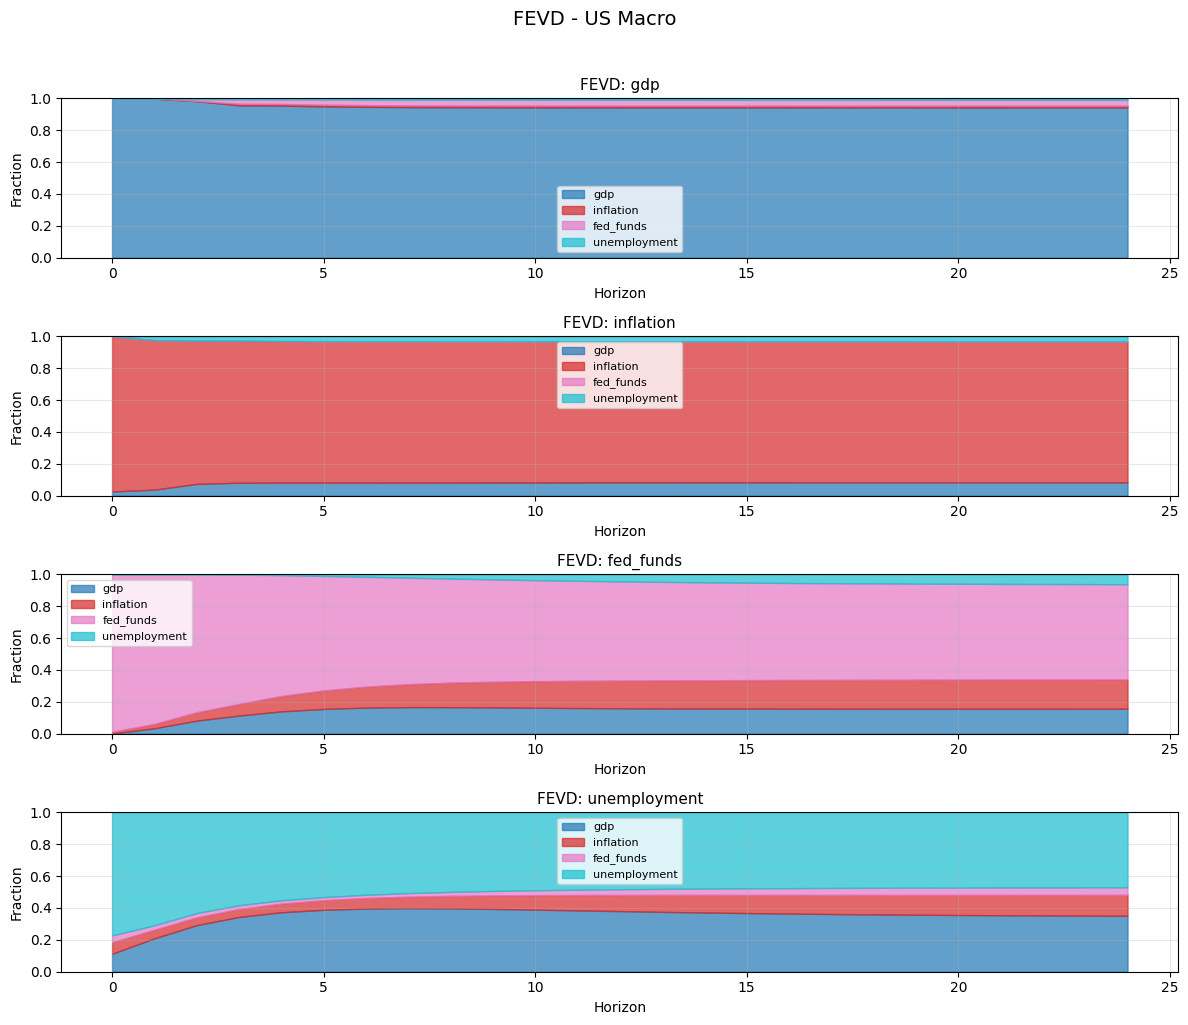

In [19]:
# FEVD for US macro
us_fevd = us_results.fevd(periods=24, method="cholesky")

fig = us_fevd.plot(figsize=(12, 10))
plt.suptitle("FEVD - US Macro", fontsize=14, y=1.02)
plt.show()

In [20]:
# FEVD tables at key horizons
us_fevd_df = us_fevd.to_dataframe()

print("US Macro FEVD at selected horizons:")
for h in [1, 4, 8, 12, 24]:
    print(f"\nHorizon = {h} quarters:")
    subset = us_fevd_df[us_fevd_df["horizon"] == h].pivot(
        index="response", columns="shock", values="fevd"
    )
    print(subset.round(4).to_string())

US Macro FEVD at selected horizons:

Horizon = 1 quarters:
shock         fed_funds     gdp  inflation  unemployment
response                                                
fed_funds        0.9388  0.0343     0.0270        0.0000
gdp              0.0001  0.9981     0.0012        0.0006
inflation        0.0008  0.0380     0.9377        0.0235
unemployment     0.0274  0.2096     0.0539        0.7091

Horizon = 4 quarters:
shock         fed_funds     gdp  inflation  unemployment
response                                                
fed_funds        0.7579  0.1402     0.0967        0.0052
gdp              0.0290  0.9544     0.0100        0.0066
inflation        0.0011  0.0822     0.8873        0.0295
unemployment     0.0204  0.3731     0.0544        0.5521

Horizon = 8 quarters:
shock         fed_funds     gdp  inflation  unemployment
response                                                
fed_funds        0.6530  0.1667     0.1539        0.0265
gdp              0.0363  0.9439     0.01

In [21]:
# FEVD interpretation: how much does fed_funds explain?
print("=" * 60)
print("Fed Funds contribution to forecast error variance:")
print("=" * 60)

for var in us_names:
    ff_contrib = us_fevd_df[(us_fevd_df["response"] == var) & 
                            (us_fevd_df["shock"] == "fed_funds")]
    for h in [1, 4, 8, 24]:
        row = ff_contrib[ff_contrib["horizon"] == h]
        if len(row) > 0:
            val = row["fevd"].values[0]
            print(f"  {var:>15s} at h={h:>2d}: {val*100:>6.2f}%")
    print()

Fed Funds contribution to forecast error variance:
              gdp at h= 1:   0.01%
              gdp at h= 4:   2.90%
              gdp at h= 8:   3.63%
              gdp at h=24:   3.68%

        inflation at h= 1:   0.08%
        inflation at h= 4:   0.11%
        inflation at h= 8:   0.30%
        inflation at h=24:   0.32%

        fed_funds at h= 1:  93.88%
        fed_funds at h= 4:  75.79%
        fed_funds at h= 8:  65.30%
        fed_funds at h=24:  59.76%

     unemployment at h= 1:   2.74%
     unemployment at h= 4:   2.04%
     unemployment at h= 8:   2.48%
     unemployment at h=24:   4.74%



In [22]:
# Step 5: Save IRF results to CSV
outputs_dir = os.path.join("..", "outputs")
os.makedirs(outputs_dir, exist_ok=True)

# Save IRF as DataFrame
us_irf_df = us_irf.to_dataframe()
irf_path = os.path.join(outputs_dir, "irf_results.csv")
us_irf_df.to_csv(irf_path, index=False)

print(f"IRF results saved to {irf_path}")
print(f"Shape: {us_irf_df.shape}")
print(f"Columns: {list(us_irf_df.columns)}")
print(f"\nPreview:")
print(us_irf_df.head(10).to_string(index=False))

IRF results saved to ../outputs/irf_results.csv
Shape: (400, 6)
Columns: ['horizon', 'impulse', 'response', 'irf', 'lower', 'upper']

Preview:
 horizon   impulse     response       irf     lower     upper
       0       gdp          gdp  0.666189  0.570720  0.703300
       0       gdp    inflation  0.082201 -0.007186  0.153347
       0       gdp    fed_funds -0.011670 -0.062534  0.041933
       0       gdp unemployment -0.103624 -0.135804 -0.061789
       0 inflation          gdp  0.000000  0.000000  0.000000
       0 inflation    inflation  0.495561  0.421098  0.524699
       0 inflation    fed_funds  0.042759 -0.010951  0.094739
       0 inflation unemployment  0.083350  0.043780  0.111576
       0 fed_funds          gdp  0.000000  0.000000  0.000000
       0 fed_funds    inflation  0.000000  0.000000  0.000000


In [23]:
# Save FEVD results to CSV
fevd_path = os.path.join(outputs_dir, "fevd_results.csv")
us_fevd_df.to_csv(fevd_path, index=False)

print(f"FEVD results saved to {fevd_path}")
print(f"Shape: {us_fevd_df.shape}")
print(f"Columns: {list(us_fevd_df.columns)}")
print(f"\nPreview:")
print(us_fevd_df.head(10).to_string(index=False))

FEVD results saved to ../outputs/fevd_results.csv
Shape: (400, 4)
Columns: ['horizon', 'response', 'shock', 'fevd']

Preview:
 horizon  response        shock     fevd
       0       gdp          gdp 1.000000
       0       gdp    inflation 0.000000
       0       gdp    fed_funds 0.000000
       0       gdp unemployment 0.000000
       0 inflation          gdp 0.026777
       0 inflation    inflation 0.973223
       0 inflation    fed_funds 0.000000
       0 inflation unemployment 0.000000
       0 fed_funds          gdp 0.000827
       0 fed_funds    inflation 0.011098


---

## Exercise 2: Variable ordering sensitivity (SOLUTION)

Reorder as `U -> rw -> prod -> e` and compare with the original Cholesky IRF.

In [24]:
# Reorder variables
reorder_names = ["U", "rw", "prod", "e"]
reorder_endog = df[reorder_names].values

reorder_model = VAR(lags=2, trend="c")
reorder_results = reorder_model.fit(reorder_endog, names=reorder_names)

irf_reorder = reorder_results.irf(periods=20, method="cholesky", sigs=0.95, runs=200)

print(f"Original ordering: {var_names}")
print(f"Reordered: {reorder_names}")

Original ordering: ['e', 'prod', 'rw', 'U']
Reordered: ['U', 'rw', 'prod', 'e']


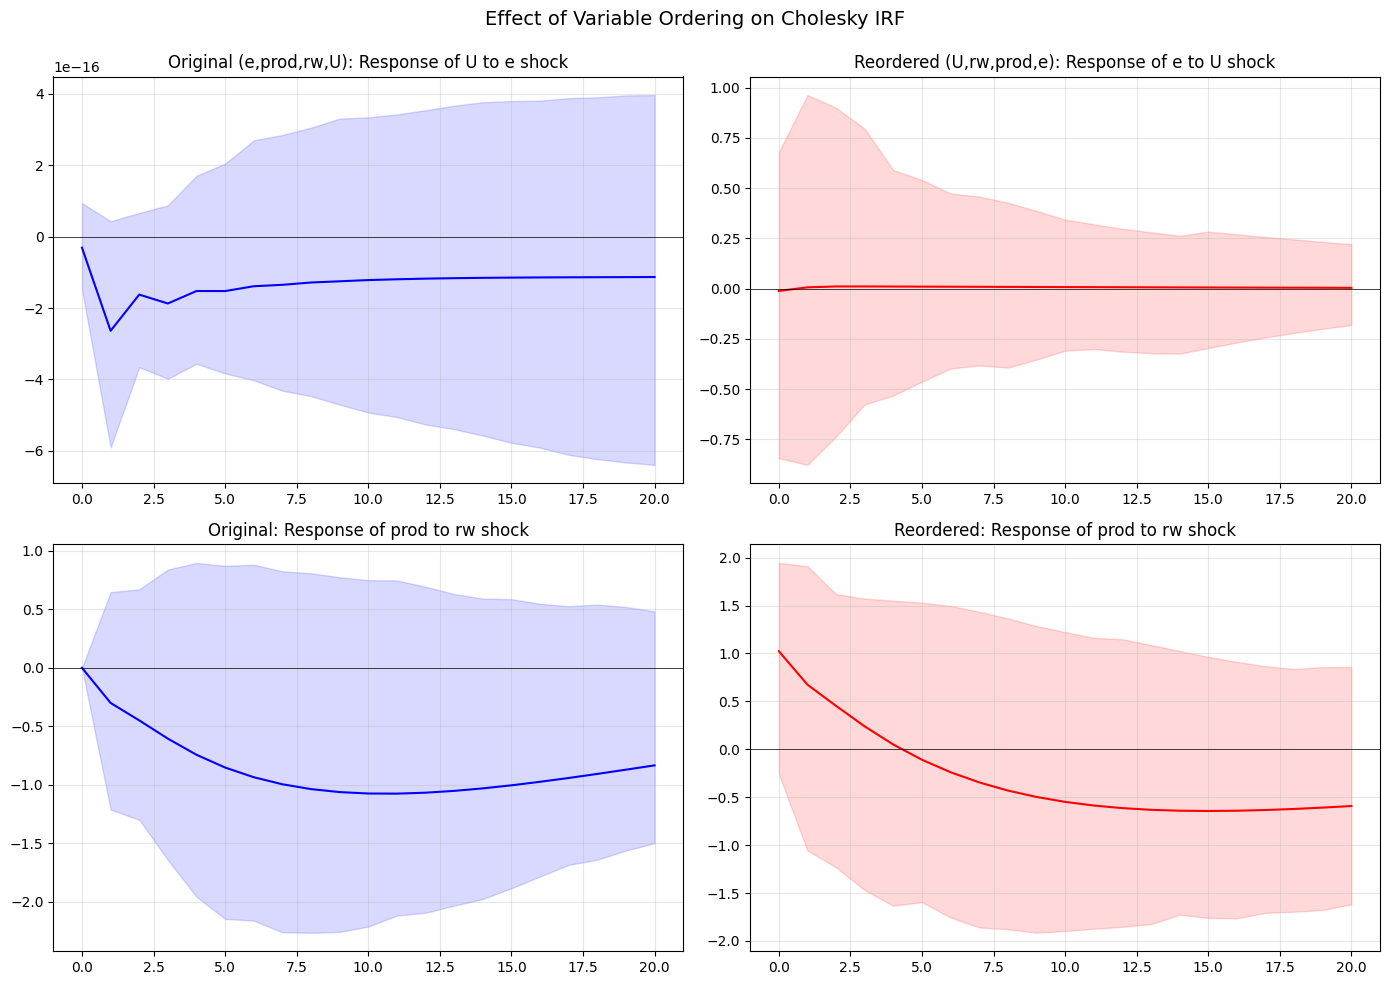

In [25]:
# Compare IRFs for the same economic response
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
h = np.arange(irf_cholesky.irfs.shape[0])

# Original: response of U to e shock
ax = axes[0, 0]
ax.plot(h, irf_cholesky.irfs[:, 3, 0], "b-", linewidth=1.5)
if irf_cholesky.lower is not None:
    ax.fill_between(h, irf_cholesky.lower[:, 3, 0], irf_cholesky.upper[:, 3, 0],
                    alpha=0.15, color="blue")
ax.axhline(0, color="k", linewidth=0.5)
ax.set_title("Original (e,prod,rw,U): Response of U to e shock")
ax.grid(True, alpha=0.3)

# Reordered: response of e to U shock (same variables, different ordering)
ax = axes[0, 1]
ax.plot(h, irf_reorder.irfs[:, 3, 0], "r-", linewidth=1.5)
if irf_reorder.lower is not None:
    ax.fill_between(h, irf_reorder.lower[:, 3, 0], irf_reorder.upper[:, 3, 0],
                    alpha=0.15, color="red")
ax.axhline(0, color="k", linewidth=0.5)
ax.set_title("Reordered (U,rw,prod,e): Response of e to U shock")
ax.grid(True, alpha=0.3)

# Original: response of prod to rw shock
ax = axes[1, 0]
ax.plot(h, irf_cholesky.irfs[:, 1, 2], "b-", linewidth=1.5)
if irf_cholesky.lower is not None:
    ax.fill_between(h, irf_cholesky.lower[:, 1, 2], irf_cholesky.upper[:, 1, 2],
                    alpha=0.15, color="blue")
ax.axhline(0, color="k", linewidth=0.5)
ax.set_title("Original: Response of prod to rw shock")
ax.grid(True, alpha=0.3)

# Reordered: same response (prod=idx2, rw=idx1 in reordered)
ax = axes[1, 1]
ax.plot(h, irf_reorder.irfs[:, 2, 1], "r-", linewidth=1.5)
if irf_reorder.lower is not None:
    ax.fill_between(h, irf_reorder.lower[:, 2, 1], irf_reorder.upper[:, 2, 1],
                    alpha=0.15, color="red")
ax.axhline(0, color="k", linewidth=0.5)
ax.set_title("Reordered: Response of prod to rw shock")
ax.grid(True, alpha=0.3)

plt.suptitle("Effect of Variable Ordering on Cholesky IRF", fontsize=14)
plt.tight_layout()
plt.show()

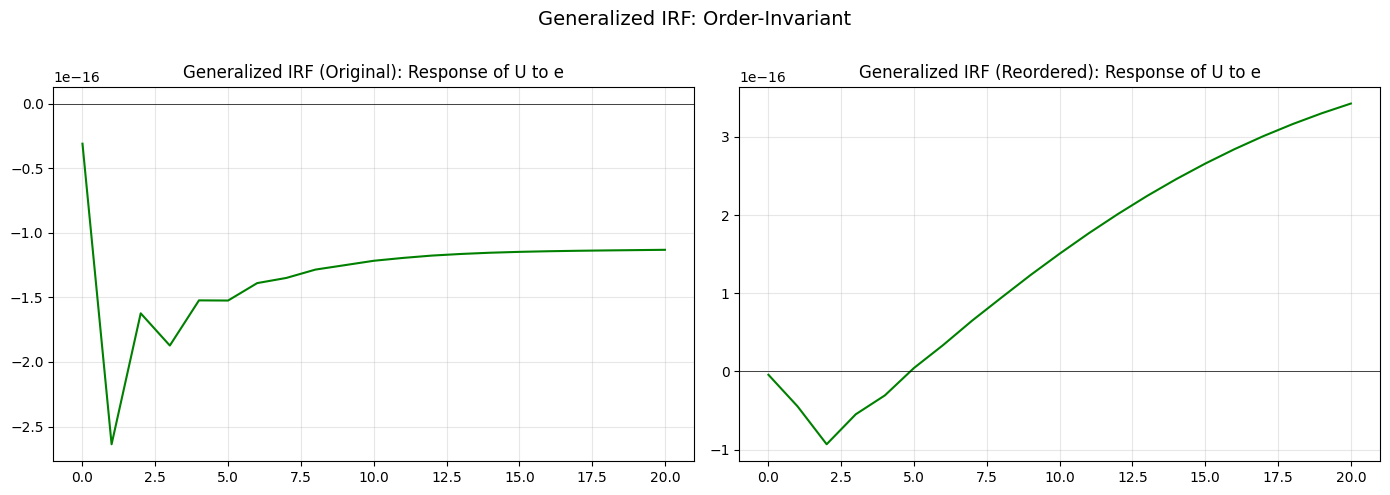

Max absolute difference between orderings (Generalized): 0.000000
Generalized IRF is invariant to variable ordering (differences are numerical noise).


In [26]:
# Compare with Generalized IRF (order-invariant)
irf_gen_orig = results.irf(periods=20, method="generalized", sigs=0.95, runs=200)
irf_gen_reorder = reorder_results.irf(periods=20, method="generalized", sigs=0.95, runs=200)

# Response of U to e (or e to U in reordered), using generalized
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(h, irf_gen_orig.irfs[:, 3, 0], "g-", linewidth=1.5, label="Original order")
ax.set_title("Generalized IRF (Original): Response of U to e")
ax.axhline(0, color="k", linewidth=0.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
# In reordered: e is index 3, U is index 0
ax.plot(h, irf_gen_reorder.irfs[:, 0, 3], "g-", linewidth=1.5, label="Reordered")
ax.set_title("Generalized IRF (Reordered): Response of U to e")
ax.axhline(0, color="k", linewidth=0.5)
ax.grid(True, alpha=0.3)

plt.suptitle("Generalized IRF: Order-Invariant", fontsize=14)
plt.tight_layout()
plt.show()

# Check numerical equivalence
diff = np.abs(irf_gen_orig.irfs[:, 3, 0] - irf_gen_reorder.irfs[:, 0, 3]).max()
print(f"Max absolute difference between orderings (Generalized): {diff:.6f}")
print("Generalized IRF is invariant to variable ordering (differences are numerical noise).")

In [27]:
print("=" * 60)
print("ORDERING SENSITIVITY SUMMARY")
print("=" * 60)
print()
print("1. Cholesky IRF is SENSITIVE to variable ordering.")
print("   - The first variable is treated as most exogenous.")
print("   - Different orderings yield different contemporaneous responses.")
print("   - Long-run responses tend to converge across orderings.")
print()
print("2. Generalized IRF is INVARIANT to variable ordering.")
print("   - It accounts for the correlation structure of shocks.")
print("   - Preferred when no strong theoretical ordering exists.")
print()
print("3. Practical recommendation:")
print("   - Use Cholesky when theory suggests a clear causal ordering.")
print("   - Use Generalized for robustness checks or agnostic analysis.")
print("   - Always report ordering sensitivity in empirical work.")

ORDERING SENSITIVITY SUMMARY

1. Cholesky IRF is SENSITIVE to variable ordering.
   - The first variable is treated as most exogenous.
   - Different orderings yield different contemporaneous responses.
   - Long-run responses tend to converge across orderings.

2. Generalized IRF is INVARIANT to variable ordering.
   - It accounts for the correlation structure of shocks.
   - Preferred when no strong theoretical ordering exists.

3. Practical recommendation:
   - Use Cholesky when theory suggests a clear causal ordering.
   - Use Generalized for robustness checks or agnostic analysis.
   - Always report ordering sensitivity in empirical work.


---

## Summary

In this solution notebook we:

1. Computed Cholesky and Generalized IRFs on Canadian data
2. **Exercise 1**: Analyzed monetary policy shocks on US macro with full interpretation
3. **Exercise 2**: Demonstrated ordering sensitivity of Cholesky vs invariance of Generalized IRF
4. Saved all outputs:
   - `outputs/irf_results.csv` - Full IRF results for US macro
   - `outputs/fevd_results.csv` - Full FEVD results for US macro